# Bradley–Terry per-person analysis

Fits a plain Bradley–Terry model per person on `food_rescue_combined copy.csv`, then computes sx/sy scores for each comparison pair.

**Features used:** size, access, income, poverty, last_donation, dist  
**Dropped:** total_donation (scale inconsistency)

**Sign corrections** (so higher processed value = higher donation priority):
| Feature | Raw direction | Sign | Rationale |
|---|---|---|---|
| size | 0–4 | +1 | Larger org serves more clients |
| access | 0–2 | +1 | Higher = worse food access = more need |
| income | 0–5 | −1 | Higher index = richer = less need |
| poverty | 0–7 | +1 | Higher = more poverty = more need |
| last_donation | 0–12 | −1 | Higher = more recent = less urgency |
| dist | 0–3 | −1 | Higher = farther = less convenient |


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import minimize

df = pd.read_csv('food_rescue_combined copy.csv')

FEATURES = ['size', 'access', 'income', 'poverty', 'last_donation', 'dist']
# +1 = keep (higher raw = higher priority), -1 = flip
SIGN = np.array([1, 1, -1, 1, -1, -1], dtype=float)

# Global min/max for normalisation (computed once across all rows)
all_vals = np.concatenate([
    df[[f+'_A' for f in FEATURES]].values,
    df[[f+'_B' for f in FEATURES]].values
], axis=0)
F_MIN = all_vals.min(axis=0)   # shape (6,)
F_MAX = all_vals.max(axis=0)   # shape (6,)
print('Global feature ranges (raw):')
for i, f in enumerate(FEATURES):
    print(f'  {f:15s}  [{F_MIN[i]:.0f}, {F_MAX[i]:.0f}]')


Global feature ranges (raw):
  size             [0, 4]
  access           [0, 2]
  income           [0, 5]
  poverty          [0, 7]
  last_donation    [0, 12]
  dist             [0, 3]


In [23]:
def process_features(raw):
    """Normalise to [0,1] then sign-correct so higher = higher donation priority."""
    rng = np.where(F_MAX > F_MIN, F_MAX - F_MIN, 1.0)
    normed = (raw - F_MIN) / rng
    # SIGN=-1: flip so low raw value -> high priority score
    signed = np.where(SIGN == 1, normed, 1.0 - normed)
    return signed   # all in [0, 1], higher = more deserving of donation


def simplex_project(w):
    """Project onto probability simplex: clip negatives, normalise."""
    w_pos = np.clip(w, 0, None)
    total = w_pos.sum()
    if total == 0:
        return np.ones(len(w)) / len(w)
    return w_pos / total


def fit_plain_bt(dx, y):
    """Fit plain BT: P(y=1) = sigmoid(dx @ w), no intercept. Returns w."""
    w0 = np.zeros(dx.shape[1])

    def nll(w):
        z = dx @ w
        return float(np.sum(np.logaddexp(0, z) - y * z))

    def grad(w):
        z = dx @ w
        p = expit(z)
        return dx.T @ (p - y)

    res = minimize(nll, w0, jac=grad, method='L-BFGS-B',
                   options={'maxiter': 2000, 'ftol': 1e-15, 'gtol': 1e-9})
    if not res.success:
        import warnings
        warnings.warn(f'BT optimiser: {res.message}')
    return res.x


print('Helper functions defined.')


Helper functions defined.


In [24]:
# Pre-process all feature columns globally
xA_all = process_features(df[[f+'_A' for f in FEATURES]].values)  # (N, 6)
xB_all = process_features(df[[f+'_B' for f in FEATURES]].values)  # (N, 6)
dx_all = xA_all - xB_all                                           # (N, 6)  A minus B

# For sx/sy normalisation: max |dx| per feature across all comparisons
DX_SCALE = np.abs(dx_all).max(axis=0)                              # (6,)
DX_SCALE = np.where(DX_SCALE > 0, DX_SCALE, 1.0)

df['y'] = (df['AorB'] == 'A').astype(float)   # 1 = chose A

# Store processed diffs in df for per-person slicing
for i, f in enumerate(FEATURES):
    df[f'dx_{f}'] = dx_all[:, i]

persons = sorted(df['personID'].unique())
print(f'{len(persons)} persons: {persons}')


19 persons: ['D1', 'D2', 'D5', 'F1', 'F2', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'V1', 'V2', 'V3', 'V5', 'V6', 'V7']


In [25]:
results = {}   # person_id -> dict with omega, sx, sy, kappa, r, acc, ...
dx_cols = [f'dx_{f}' for f in FEATURES]

for pid in persons:
    sub   = df[df['personID'] == pid].copy()
    dx    = sub[dx_cols].values    # (T, 6)
    y     = sub['y'].values        # (T,)

    # Fit BT
    w_hat = fit_plain_bt(dx, y)
    omega = simplex_project(w_hat)

    # In-sample accuracy
    acc = ((dx @ w_hat >= 0).astype(float) == y).mean()

    # sx / sy: normalise diffs so each feature is in [-1, 1]
    dx_norm = dx / DX_SCALE
    r     = (np.abs(dx_norm) * omega).sum(axis=1)  # unsigned intensity
    kappa = (dx_norm * omega).sum(axis=1)           # signed preference (+->A, -->B)
    sy    = (r + kappa) / 2   # score of A  = s(A, B)
    sx    = (r - kappa) / 2   # score of B  = s(B, A)

    results[pid] = dict(w_hat=w_hat, omega=omega,
                        r=r, kappa=kappa, sy=sy, sx=sx,
                        acc=acc, T=len(y),
                        choice=sub['AorB'].values, sub=sub)

print('BT fits complete.\n')
header = '  '.join(f'{f[:5]:>6s}' for f in FEATURES)
print(f'{"Person":8s}  {"T":>4s}  {"Acc":>6s}  {header}')
for pid, res in results.items():
    om = '  '.join(f'{v:6.3f}' for v in res['omega'])
    print(f'{pid:8s}  {res["T"]:>4d}  {res["acc"]:>5.1%}  {om}')


BT fits complete.

Person       T     Acc    size   acces   incom   pover   last_    dist
D1          47  91.5%   0.221   0.390   0.047   0.319   0.000   0.023
D2          45  80.0%   0.179   0.275   0.000   0.367   0.030   0.149
D5          49  95.9%   0.037   0.000   0.633   0.114   0.057   0.158
F1          45  82.2%   0.000   0.013   0.000   0.645   0.000   0.343
F2          45  86.7%   0.255   0.049   0.113   0.188   0.000   0.394
R1          40  95.0%   0.035   0.098   0.155   0.617   0.096   0.000
R2          45  88.9%   0.498   0.303   0.000   0.059   0.050   0.091
R3          47  89.4%   0.365   0.179   0.154   0.000   0.081   0.222
R4          45  91.1%   0.006   0.225   0.281   0.488   0.000   0.000
R5          45  71.1%   0.300   0.071   0.000   0.029   0.000   0.600
R6          48  89.6%   0.026   0.154   0.820   0.000   0.000   0.000
R7          47  87.2%   0.000   0.161   0.000   0.523   0.116   0.201
R8          47  100.0%   0.000   0.206   0.000   0.489   0.073   0.232

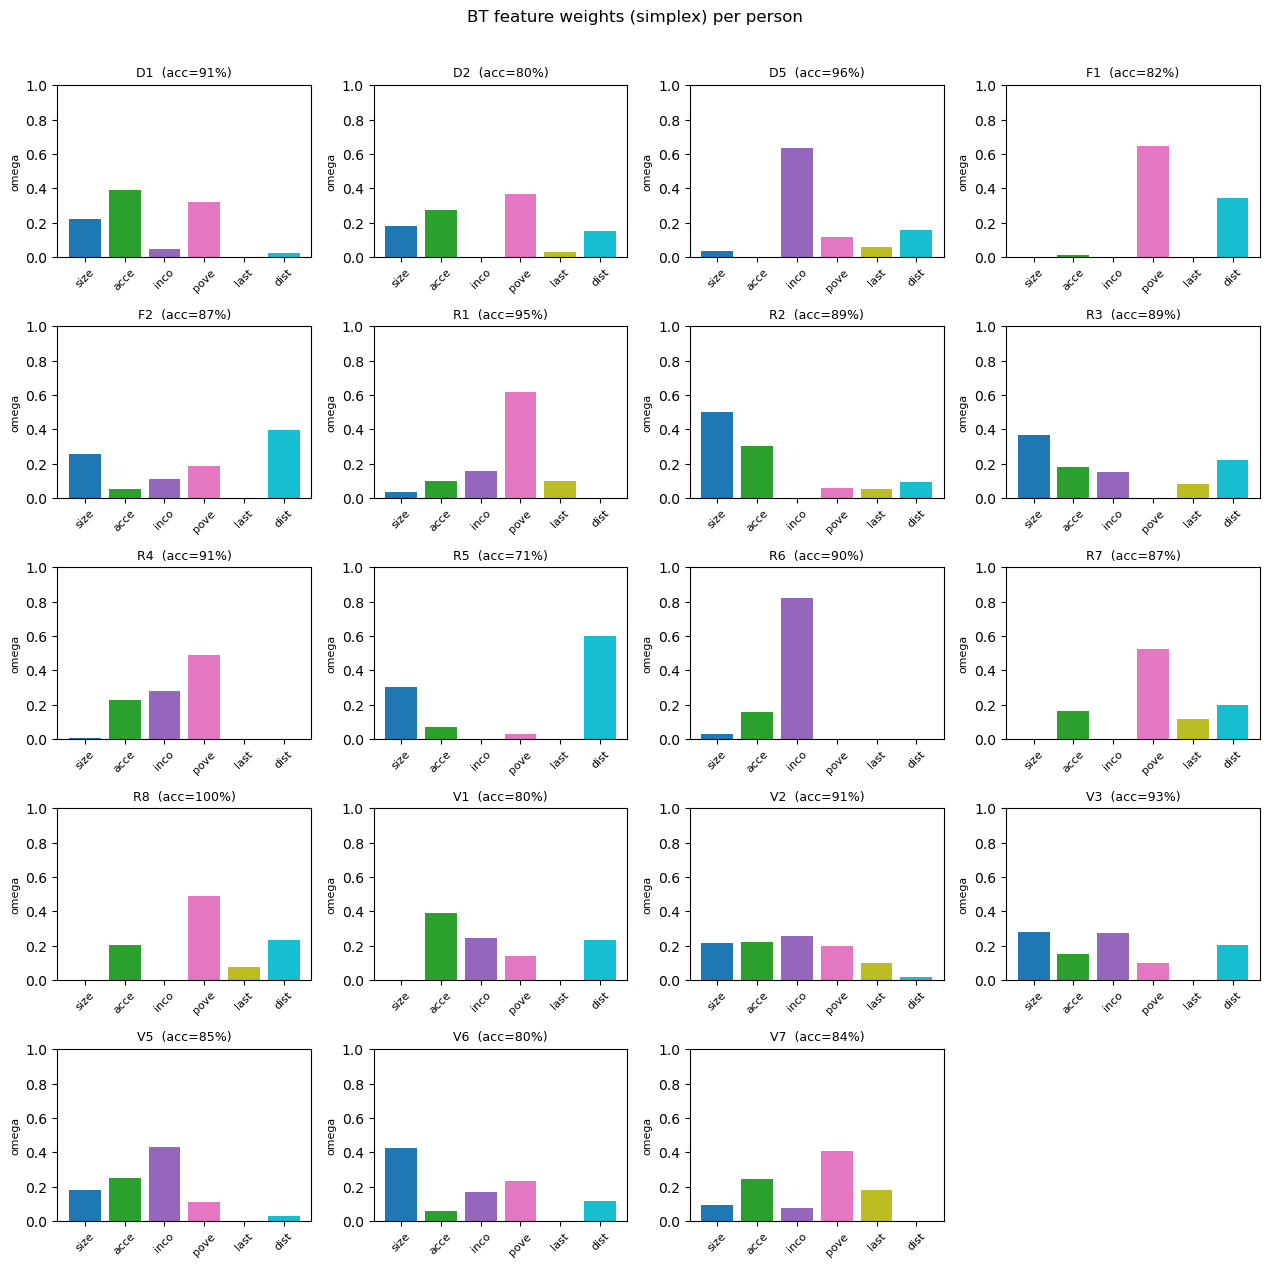

Saved bt_omega_per_person.png


In [26]:
n = len(persons)
ncols, nrows = 4, (n + 3) // 4
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.5))
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, len(FEATURES)))

for ax, pid in zip(axes, persons):
    omega = results[pid]['omega']
    ax.bar(range(len(FEATURES)), omega, color=colors)
    ax.set_xticks(range(len(FEATURES)))
    ax.set_xticklabels([f[:4] for f in FEATURES], fontsize=8, rotation=45)
    ax.set_ylim(0, 1)
    ax.set_title(f'{pid}  (acc={results[pid]["acc"]:.0%})', fontsize=9)
    ax.set_ylabel('omega', fontsize=8)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('BT feature weights (simplex) per person', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('bt_omega_per_person.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved bt_omega_per_person.png')


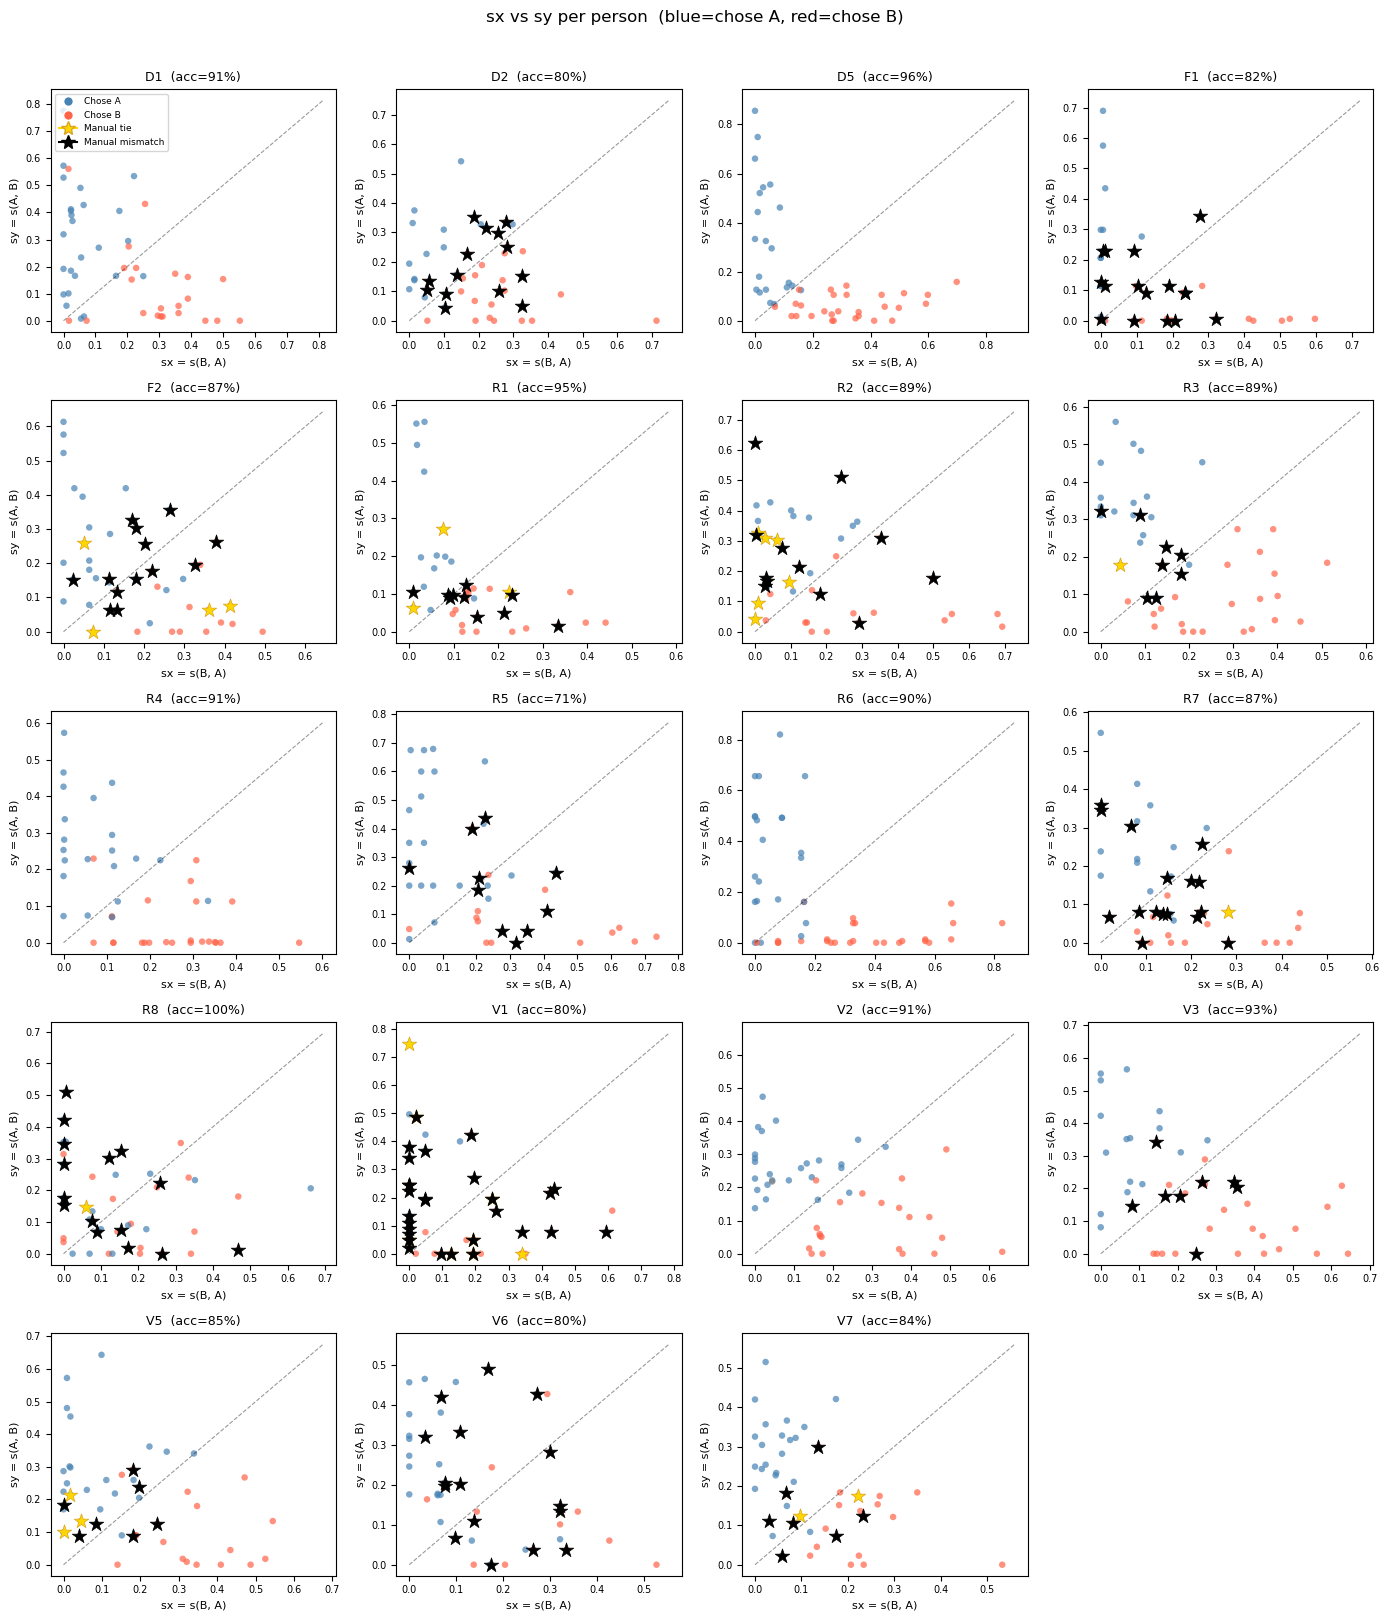

Saved bt_sxsy_per_person.png


In [27]:
from matplotlib.lines import Line2D
import pandas as pd

ties_df      = pd.read_csv('ties.csv')[['personID','num_Q']]
mismatch_df  = pd.read_csv('mismatches.csv')[['personID','num_Q']]

ncols, nrows = 4, (n + 3) // 4
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2))
axes = axes.flatten()

choice_color = {'A': 'steelblue', 'B': 'tomato'}

for ax, pid in zip(axes, persons):
    res = results[pid]
    sx, sy   = res['sx'], res['sy']
    sub_idx  = res['sub']['num_Q'].values
    choice   = res['choice']
    colors_pt = [choice_color.get(c, 'gray') for c in choice]

    # Base scatter
    ax.scatter(sx, sy, c=colors_pt, alpha=0.7, s=22, linewidths=0)

    # y=x reference line
    lim = max(sx.max(), sy.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4)

    # Tied queries: yellow star
    tie_qs = set(ties_df[ties_df['personID'] == pid]['num_Q'])
    tie_mask = np.isin(sub_idx, list(tie_qs))
    if tie_mask.any():
        ax.scatter(sx[tie_mask], sy[tie_mask],
                   marker='*', s=120, color='gold',
                   edgecolors='goldenrod', linewidths=0.5, zorder=5)

    # Mismatched queries: black star
    mis_qs = set(mismatch_df[mismatch_df['personID'] == pid]['num_Q'])
    mis_mask = np.isin(sub_idx, list(mis_qs))
    if mis_mask.any():
        ax.scatter(sx[mis_mask], sy[mis_mask],
                   marker='*', s=120, color='black',
                   edgecolors='black', linewidths=0.5, zorder=6)

    ax.set_xlabel('sx = s(B, A)', fontsize=8)
    ax.set_ylabel('sy = s(A, B)', fontsize=8)
    ax.set_title(f'{pid}  (acc={res["acc"]:.0%})', fontsize=9)
    ax.tick_params(labelsize=7)

legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=7, label='Chose A'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
           markersize=7, label='Chose B'),
    Line2D([0],[0], marker='*', color='gold', markeredgecolor='goldenrod',
           markersize=10, label='Manual tie'),
    Line2D([0],[0], marker='*', color='black',
           markersize=10, label='Manual mismatch'),
]
axes[0].legend(handles=legend_els, fontsize=6.5, loc='upper left')

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('sx vs sy per person  (blue=chose A, red=chose B)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('bt_sxsy_per_person.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved bt_sxsy_per_person.png')


In [28]:
# Save per-comparison scores to CSV
rows = []
for pid, res in results.items():
    sub = res['sub'].copy()
    sub['r']      = res['r']
    sub['kappa']  = res['kappa']
    sub['sy']     = res['sy']
    sub['sx']     = res['sx']
    sub['bt_pred'] = np.where(res['sy'] > res['sx'], 'A', 'B')
    rows.append(sub)

out = pd.concat(rows, ignore_index=True)
keep_cols = ['personID','num_Q','AorB','food',
             'size_A','access_A','income_A','poverty_A','last_donation_A','dist_A',
             'size_B','access_B','income_B','poverty_B','last_donation_B','dist_B',
             'r','kappa','sy','sx','bt_pred']
out = out[keep_cols]
out.to_csv('bt_scores.csv', index=False)
print(f'Saved bt_scores.csv  ({len(out)} rows)')

# Overall BT prediction accuracy
acc_overall = (out['bt_pred'] == out['AorB']).mean()
print(f'Overall BT accuracy: {acc_overall:.1%}\n')

print(out[['personID','r','kappa','sy','sx']].groupby('personID').mean().round(3))


Saved bt_scores.csv  (867 rows)
Overall BT accuracy: 83.4%

              r  kappa     sy     sx
personID                            
D1        0.389  0.044  0.216  0.172
D2        0.357 -0.025  0.166  0.191
D5        0.386 -0.032  0.177  0.209
F1        0.263 -0.020  0.121  0.141
F2        0.366  0.003  0.185  0.182
R1        0.268 -0.003  0.132  0.136
R2        0.381  0.036  0.209  0.172
R3        0.381  0.020  0.201  0.180
R4        0.316 -0.023  0.146  0.169
R5        0.451  0.026  0.238  0.212
R6        0.402 -0.052  0.175  0.227
R7        0.303 -0.025  0.139  0.164
R8        0.313  0.002  0.158  0.155
V1        0.322  0.020  0.171  0.151
V2        0.377 -0.001  0.188  0.189
V3        0.430 -0.043  0.194  0.236
V5        0.381  0.017  0.199  0.182
V6        0.357  0.052  0.204  0.153
V7        0.318  0.069  0.194  0.124


In [29]:
# Translate manual scoring tables into approximate omega vectors.
# For each person & feature, omega_f ∝ range(manual scores for f).
# Intuition: a feature with a wider score range can swing a pairwise
# comparison more — so it contributes more weight in the linear model.

FEAT_CSV = {
    'size':          'Manual scoring model database_sheet.xlsx - organization_size.csv',
    'access':        'Manual scoring model database_sheet.xlsx - access.csv',
    'income':        'Manual scoring model database_sheet.xlsx - income.csv',
    'poverty':       'Manual scoring model database_sheet.xlsx - poverty.csv',
    'last_donation': 'Manual scoring model database_sheet.xlsx - last_donation.csv',
    'dist':          'Manual scoring model database_sheet.xlsx - distance.csv',
}

# Load each CSV and compute per-person score range
feat_ranges = {}   # feat -> {person: range}
for feat, path in FEAT_CSV.items():
    raw = pd.read_csv(path)
    raw = raw.set_index('person')
    score_cols = raw.columns.tolist()
    raw[score_cols] = raw[score_cols].apply(pd.to_numeric, errors='coerce')
    feat_ranges[feat] = (raw.max(axis=1) - raw.min(axis=1)).to_dict()

# Build omega_manual per person
omega_manual = {}   # person -> array(6)
for pid in persons:
    row = np.array([feat_ranges[f].get(pid, np.nan) for f in FEATURES])
    if np.all(np.isnan(row)) or np.nansum(row) == 0:
        omega_manual[pid] = None   # no manual model
    else:
        row = np.where(np.isnan(row), 0.0, row)   # missing feature -> 0 weight
        omega_manual[pid] = simplex_project(row)

has_manual = [p for p in persons if omega_manual[p] is not None]
print(f'Manual omega computed for {len(has_manual)} persons: {has_manual}\n')

# Print side-by-side comparison
header = '  '.join(f'{f[:5]:>6s}' for f in FEATURES)
print(f'{"Person":8s}  {"Model":8s}  {header}')
print('-' * 70)
for pid in persons:
    om_bt = results[pid]['omega']
    om_bt_str = '  '.join(f'{v:6.3f}' for v in om_bt)
    print(f'{pid:8s}  {"BT":8s}  {om_bt_str}')
    if omega_manual[pid] is not None:
        om_m = omega_manual[pid]
        om_m_str = '  '.join(f'{v:6.3f}' for v in om_m)
        print(f'{"":8s}  {"manual":8s}  {om_m_str}')
    else:
        print(f'{"":8s}  {"manual":8s}  (no manual model)')
    print()


Manual omega computed for 14 persons: ['D2', 'F1', 'F2', 'R1', 'R2', 'R3', 'R5', 'R7', 'R8', 'V1', 'V3', 'V5', 'V6', 'V7']

Person    Model       size   acces   incom   pover   last_    dist
----------------------------------------------------------------------
D1        BT         0.221   0.390   0.047   0.319   0.000   0.023
          manual    (no manual model)

D2        BT         0.179   0.275   0.000   0.367   0.030   0.149
          manual     0.070   0.302   0.233   0.186   0.140   0.070

D5        BT         0.037   0.000   0.633   0.114   0.057   0.158
          manual    (no manual model)

F1        BT         0.000   0.013   0.000   0.645   0.000   0.343
          manual     0.096   0.060   0.301   0.361   0.145   0.036

F2        BT         0.255   0.049   0.113   0.188   0.000   0.394
          manual     0.222   0.111   0.148   0.148   0.074   0.296

R1        BT         0.035   0.098   0.155   0.617   0.096   0.000
          manual     0.125   0.167   0.208   0.250   0

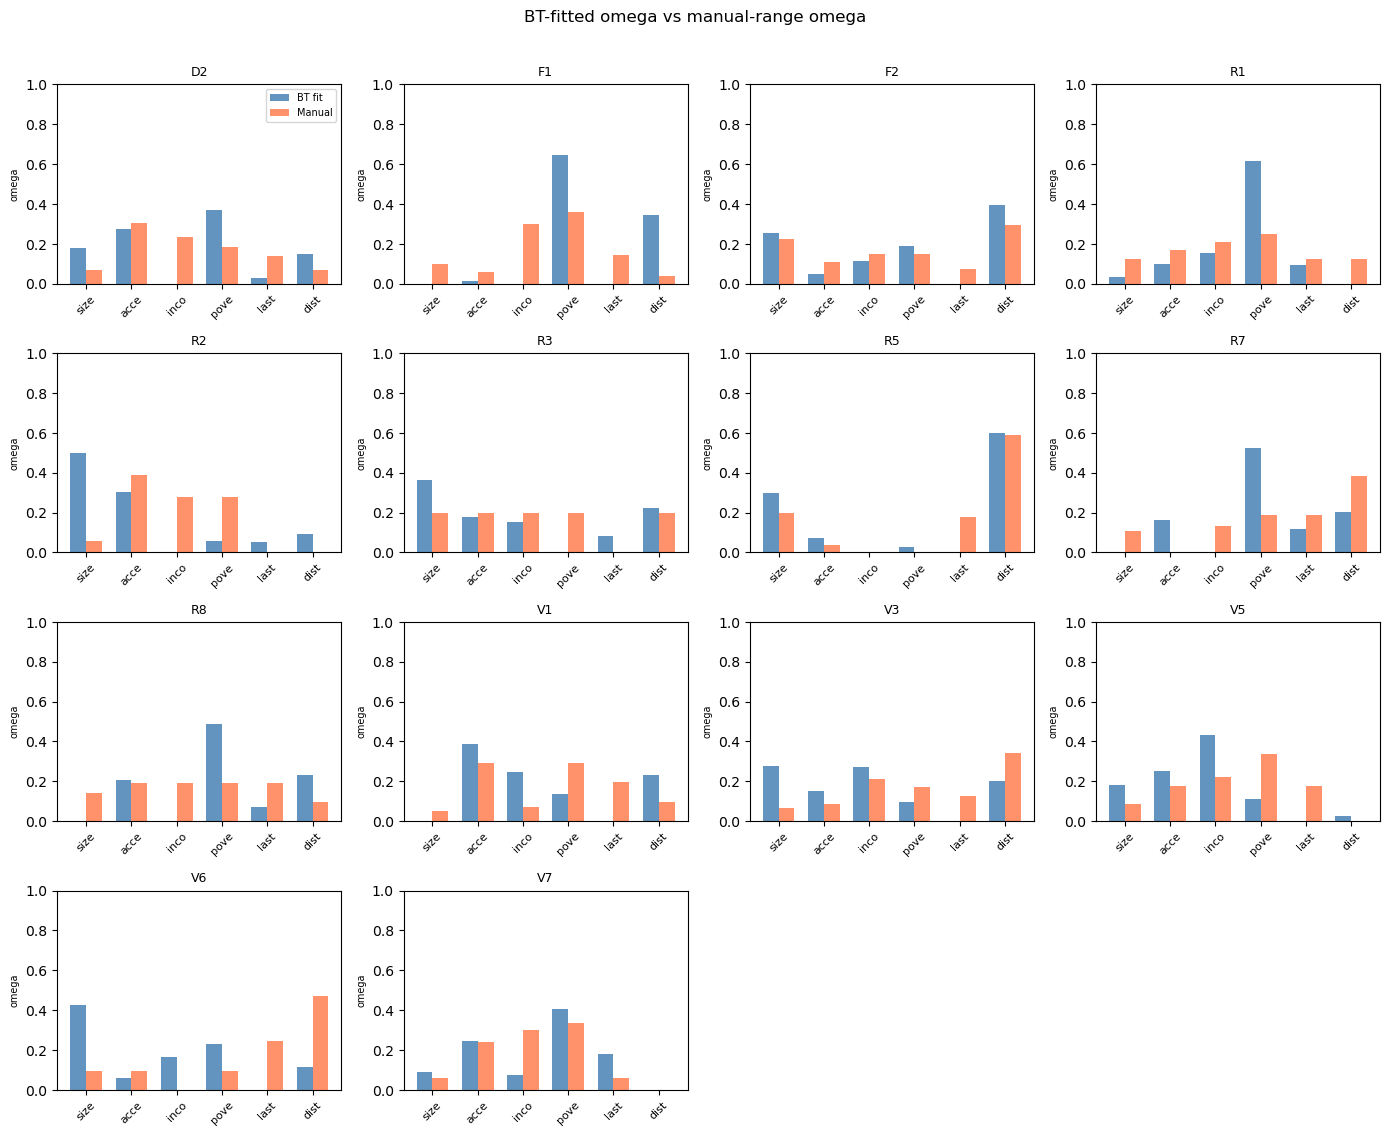

Saved bt_omega_vs_manual.png


In [30]:
# Side-by-side bar chart: BT omega vs manual omega for persons with both
pids_both = [p for p in persons if omega_manual[p] is not None]
n2 = len(pids_both)
ncols2, nrows2 = 4, (n2 + 3) // 4

fig, axes = plt.subplots(nrows2, ncols2, figsize=(ncols2 * 3.5, nrows2 * 2.8))
axes = axes.flatten()

x = np.arange(len(FEATURES))
w = 0.35

for ax, pid in zip(axes, pids_both):
    om_bt  = results[pid]['omega']
    om_man = omega_manual[pid]
    ax.bar(x - w/2, om_bt,  w, label='BT fit',  color='steelblue', alpha=0.85)
    ax.bar(x + w/2, om_man, w, label='Manual',  color='coral',     alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f[:4] for f in FEATURES], fontsize=8, rotation=45)
    ax.set_ylim(0, 1)
    ax.set_title(pid, fontsize=9)
    ax.set_ylabel('omega', fontsize=7)

axes[0].legend(fontsize=7)

for ax in axes[n2:]:
    ax.set_visible(False)

plt.suptitle('BT-fitted omega vs manual-range omega', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('bt_omega_vs_manual.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved bt_omega_vs_manual.png')


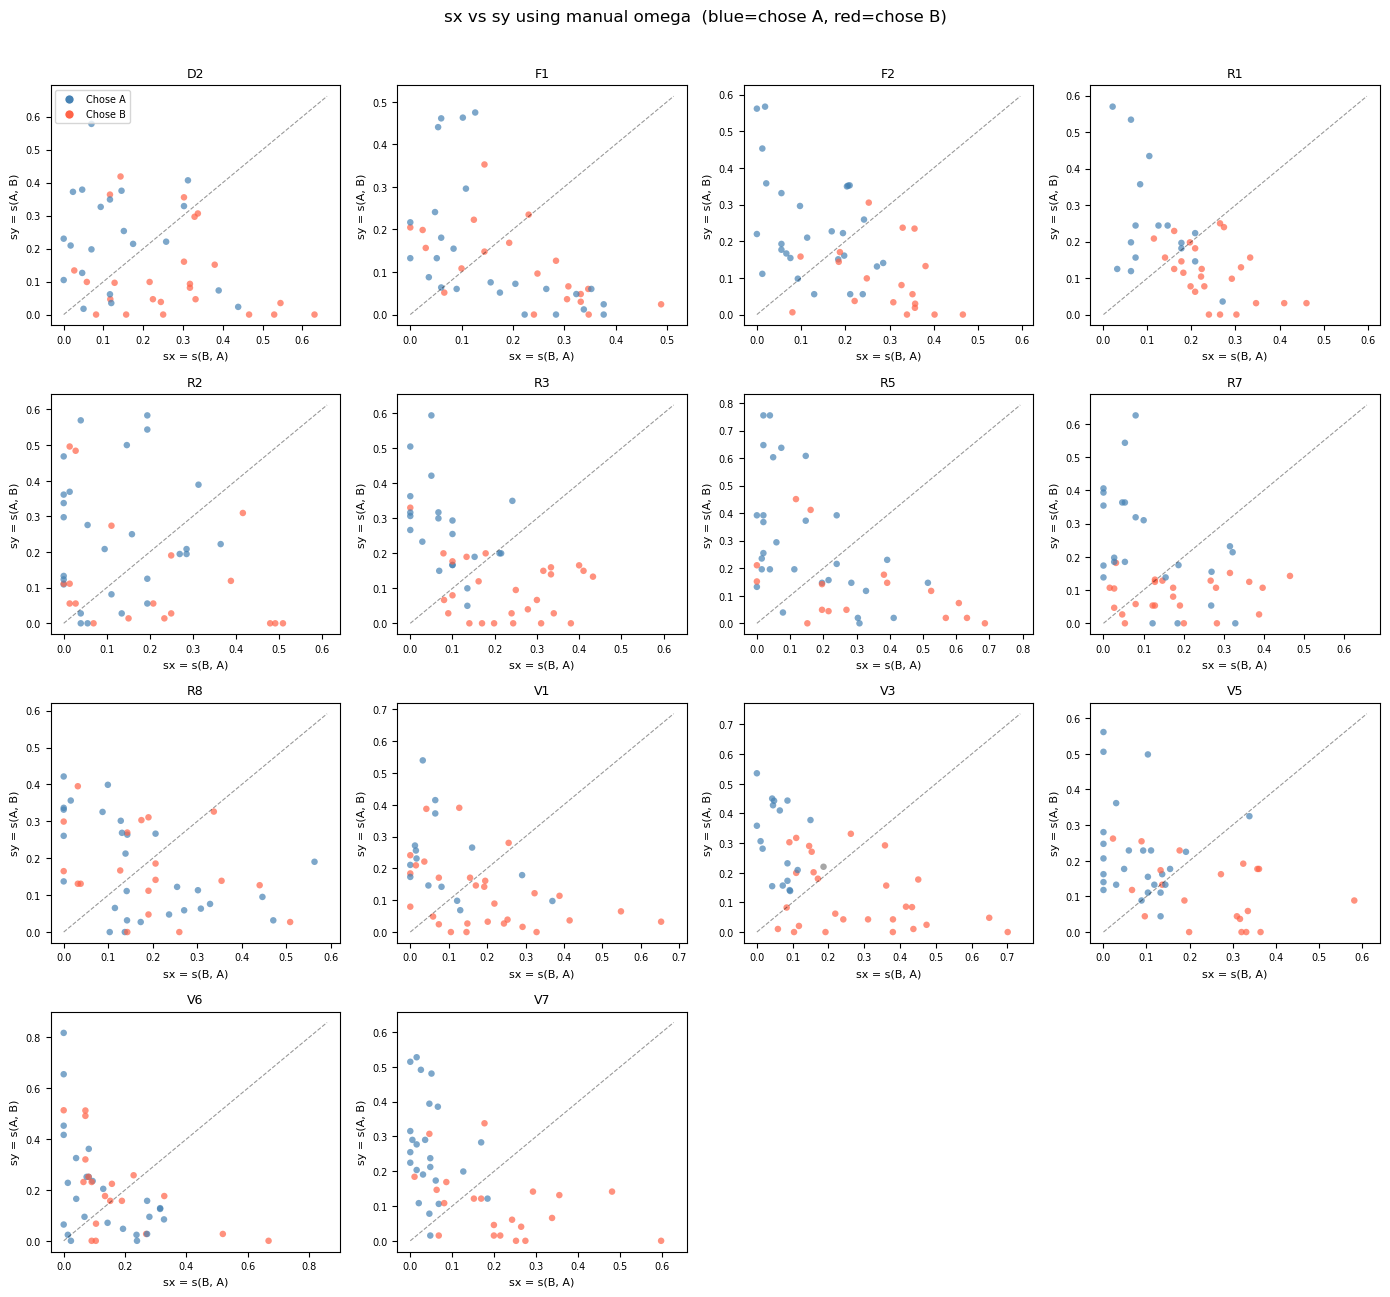

Saved manual_omega_sxsy.png


In [31]:
# sx vs sy using manual omega (persons with manual model only)
from matplotlib.lines import Line2D

pids_manual = [p for p in persons if omega_manual[p] is not None]
n_m = len(pids_manual)
ncols_m, nrows_m = 4, (n_m + 3) // 4

fig, axes = plt.subplots(nrows_m, ncols_m, figsize=(ncols_m * 3.5, nrows_m * 3.2))
axes = axes.flatten()

choice_color = {'A': 'steelblue', 'B': 'tomato'}
dx_cols = [f'dx_{f}' for f in FEATURES]

for ax, pid in zip(axes, pids_manual):
    omega = omega_manual[pid]
    sub   = results[pid]['sub']
    dx    = sub[dx_cols].values
    choice = results[pid]['choice']

    dx_norm = dx / DX_SCALE
    r     = (np.abs(dx_norm) * omega).sum(axis=1)
    kappa = (dx_norm * omega).sum(axis=1)
    sy    = (r + kappa) / 2
    sx    = (r - kappa) / 2

    colors_pt = [choice_color.get(c, 'gray') for c in choice]
    ax.scatter(sx, sy, c=colors_pt, alpha=0.7, s=22, linewidths=0)

    lim = max(sx.max(), sy.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4)

    ax.set_xlabel('sx = s(B, A)', fontsize=8)
    ax.set_ylabel('sy = s(A, B)', fontsize=8)
    ax.set_title(pid, fontsize=9)
    ax.tick_params(labelsize=7)

legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=7, label='Chose A'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
           markersize=7, label='Chose B'),
]
axes[0].legend(handles=legend_els, fontsize=7, loc='upper left')

for ax in axes[n_m:]:
    ax.set_visible(False)

plt.suptitle('sx vs sy using manual omega  (blue=chose A, red=chose B)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('manual_omega_sxsy.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved manual_omega_sxsy.png')


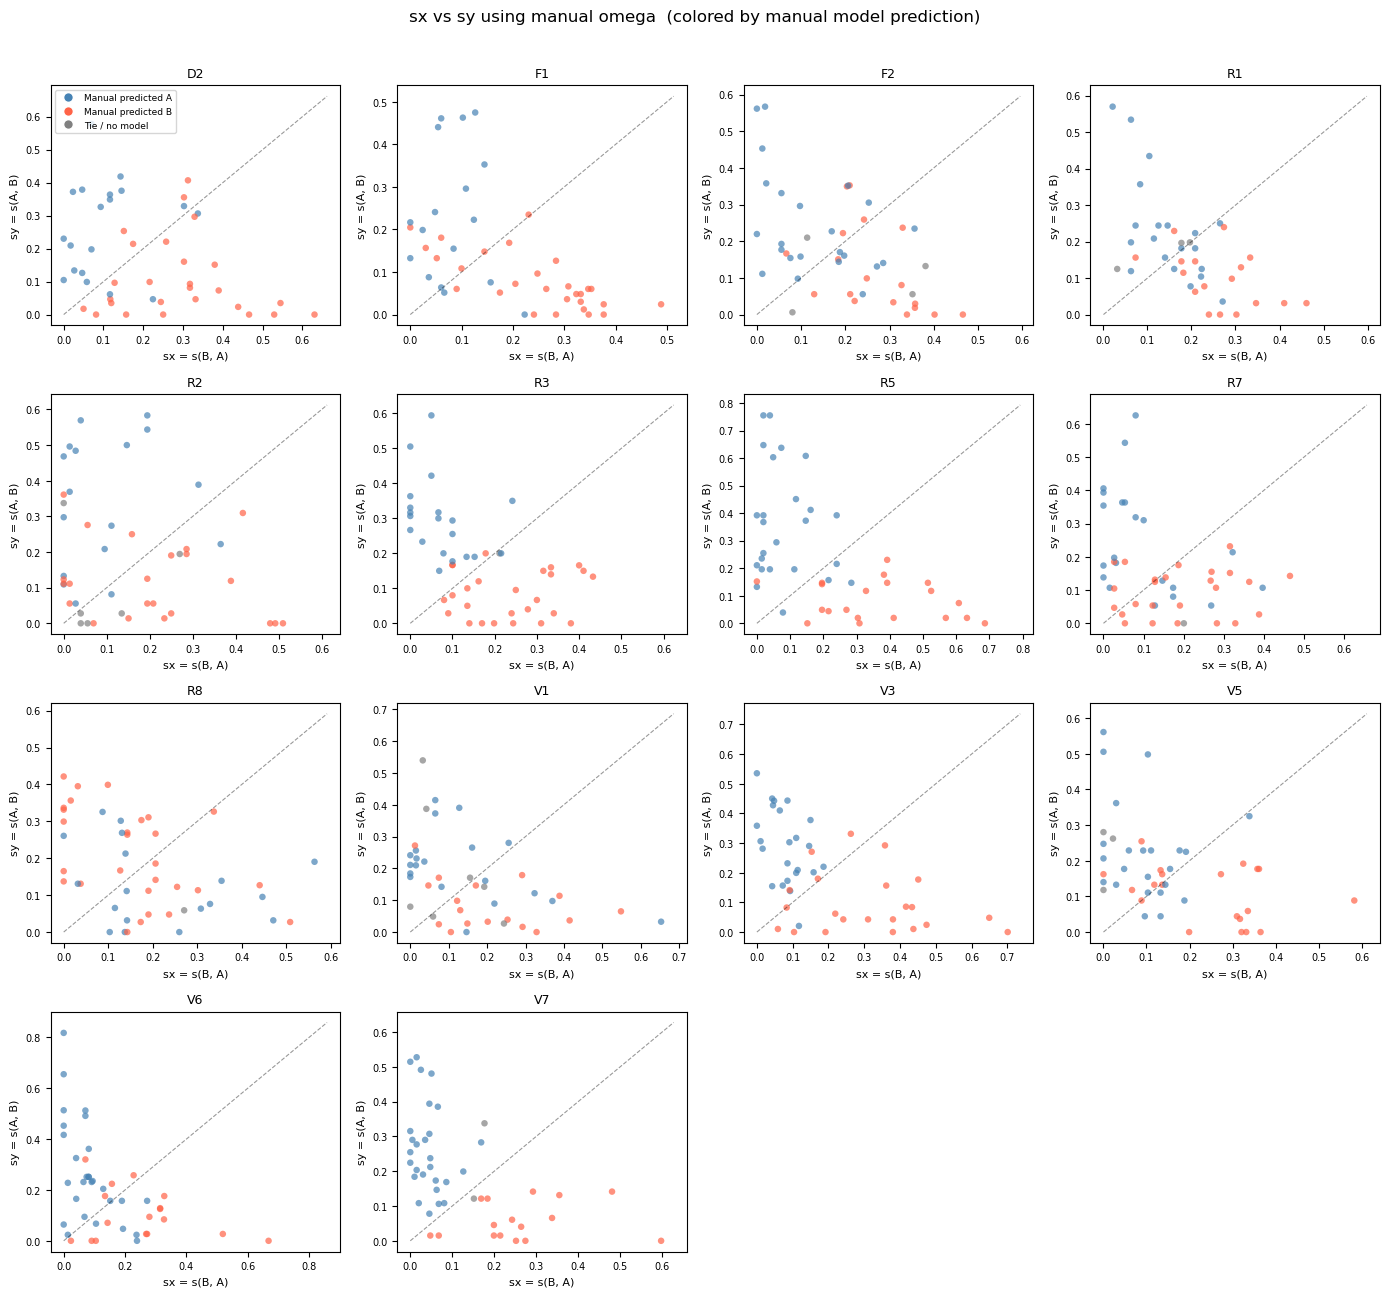

Saved manual_omega_sxsy_manual_pred.png


In [32]:
# sx vs sy using manual omega, colored by MANUAL MODEL prediction
preds = pd.read_csv('pairwise_model_predictions.csv')[['personID','num_Q','model_prediction']]
# deduplicate: some persons have multiple rows per num_Q (different food types)
preds_dedup = preds.drop_duplicates(subset=['personID','num_Q'])

fig, axes = plt.subplots(nrows_m, ncols_m, figsize=(ncols_m * 3.5, nrows_m * 3.2))
axes = axes.flatten()

for ax, pid in zip(axes, pids_manual):
    omega = omega_manual[pid]
    sub   = results[pid]['sub']
    dx    = sub[dx_cols].values

    dx_norm = dx / DX_SCALE
    r     = (np.abs(dx_norm) * omega).sum(axis=1)
    kappa = (dx_norm * omega).sum(axis=1)
    sy    = (r + kappa) / 2
    sx    = (r - kappa) / 2

    # Build num_Q -> model_prediction lookup for this person
    lookup = preds_dedup[preds_dedup['personID'] == pid].set_index('num_Q')['model_prediction']
    pred_col = sub['num_Q'].map(lookup)
    colors_pt = [choice_color.get(c, 'gray') for c in pred_col]

    ax.scatter(sx, sy, c=colors_pt, alpha=0.7, s=22, linewidths=0)

    lim = max(sx.max(), sy.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4)

    ax.set_xlabel('sx = s(B, A)', fontsize=8)
    ax.set_ylabel('sy = s(A, B)', fontsize=8)
    ax.set_title(pid, fontsize=9)
    ax.tick_params(labelsize=7)

legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=7, label='Manual predicted A'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
           markersize=7, label='Manual predicted B'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
           markersize=7, label='Tie / no model'),
]
axes[0].legend(handles=legend_els, fontsize=6.5, loc='upper left')

for ax in axes[n_m:]:
    ax.set_visible(False)

plt.suptitle('sx vs sy using manual omega  (colored by manual model prediction)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('manual_omega_sxsy_manual_pred.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved manual_omega_sxsy_manual_pred.png')


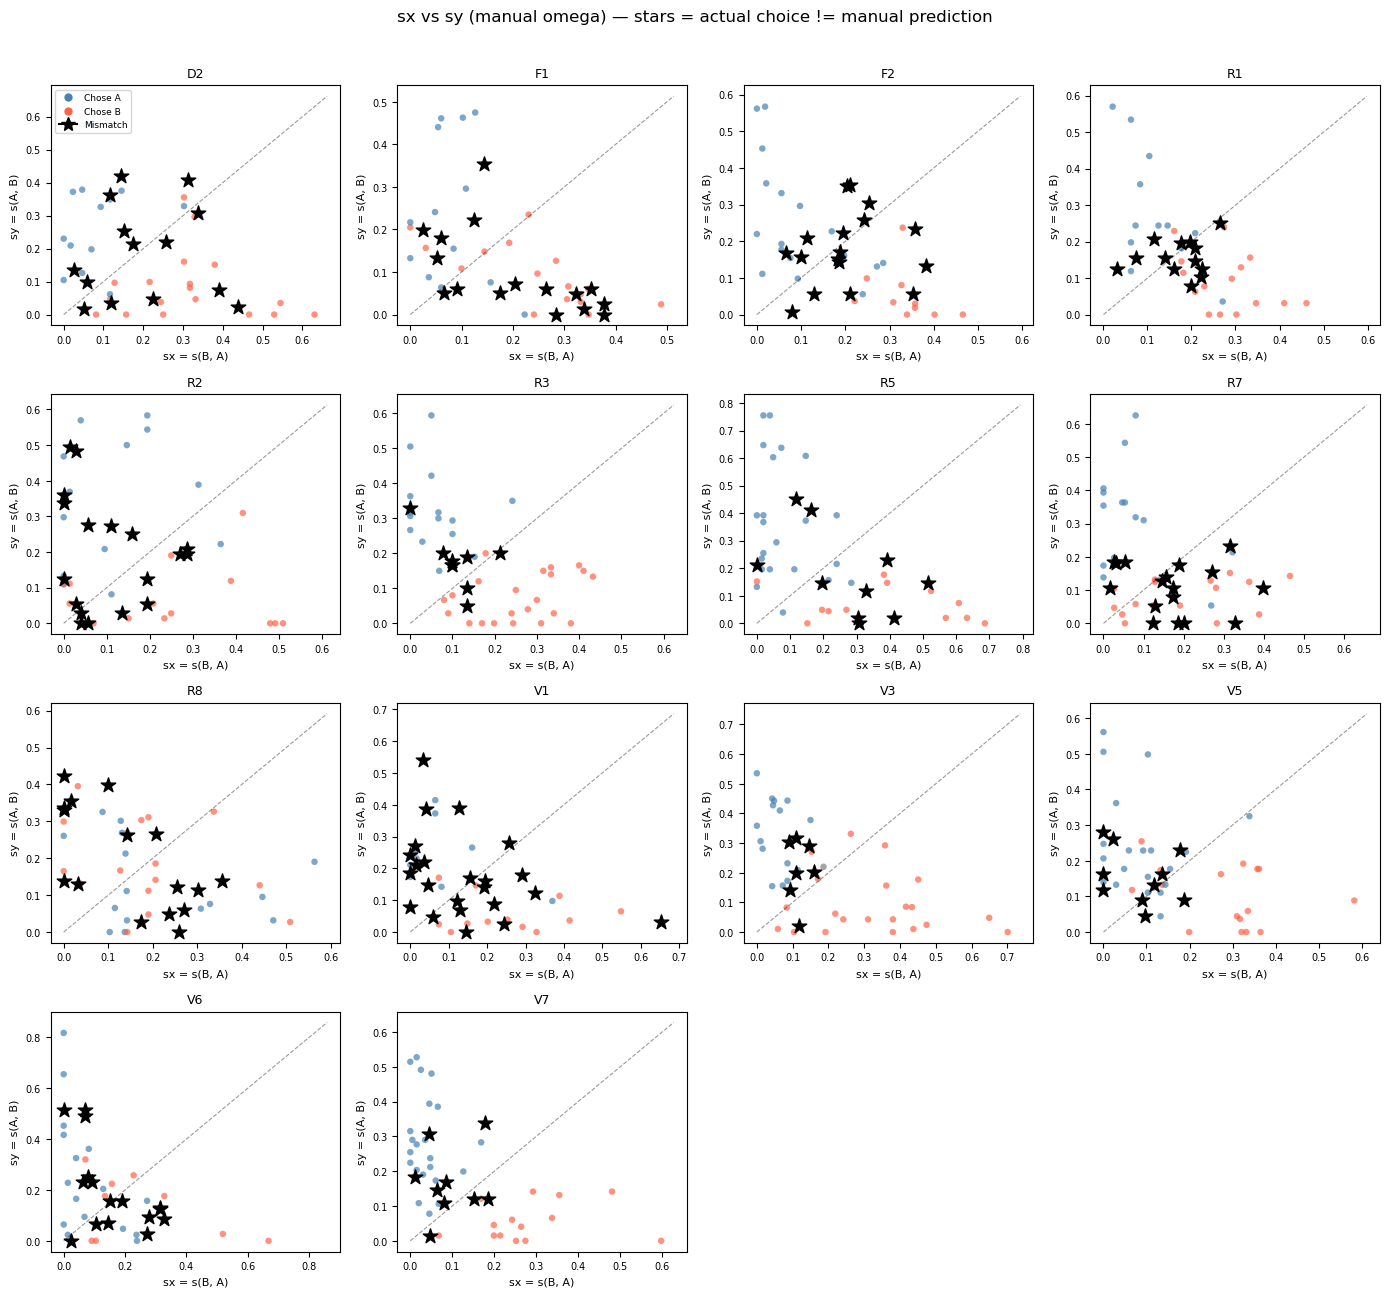

Saved manual_omega_sxsy_mismatches.png


In [33]:
# sx vs sy (manual omega, colored by actual choice) with stars on mismatches
preds_dedup = pd.read_csv('pairwise_model_predictions.csv')[['personID','num_Q','model_prediction']] \
    .drop_duplicates(subset=['personID','num_Q'])

fig, axes = plt.subplots(nrows_m, ncols_m, figsize=(ncols_m * 3.5, nrows_m * 3.2))
axes = axes.flatten()

for ax, pid in zip(axes, pids_manual):
    omega = omega_manual[pid]
    sub   = results[pid]['sub']
    dx    = sub[dx_cols].values
    choice = results[pid]['choice']

    dx_norm = dx / DX_SCALE
    r     = (np.abs(dx_norm) * omega).sum(axis=1)
    kappa = (dx_norm * omega).sum(axis=1)
    sy    = (r + kappa) / 2
    sx    = (r - kappa) / 2

    # Base scatter colored by actual choice
    colors_pt = [choice_color.get(c, 'gray') for c in choice]
    ax.scatter(sx, sy, c=colors_pt, alpha=0.7, s=22, linewidths=0)

    lim = max(sx.max(), sy.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4)

    # Star queries where actual choice != manual model prediction
    lookup = preds_dedup[preds_dedup['personID'] == pid].set_index('num_Q')['model_prediction']
    pred_col = sub['num_Q'].map(lookup).values
    mismatch_mask = np.array([
        c != p if (pd.notna(p) and pd.notna(c)) else False
        for c, p in zip(choice, pred_col)
    ])
    if mismatch_mask.any():
        ax.scatter(sx[mismatch_mask], sy[mismatch_mask],
                   marker='*', s=120, color='black', zorder=5)

    ax.set_xlabel('sx = s(B, A)', fontsize=8)
    ax.set_ylabel('sy = s(A, B)', fontsize=8)
    ax.set_title(pid, fontsize=9)
    ax.tick_params(labelsize=7)

legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=7, label='Chose A'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
           markersize=7, label='Chose B'),
    Line2D([0],[0], marker='*', color='black', markersize=10, label='Mismatch'),
]
axes[0].legend(handles=legend_els, fontsize=6.5, loc='upper left')

for ax in axes[n_m:]:
    ax.set_visible(False)

plt.suptitle('sx vs sy (manual omega) — stars = actual choice != manual prediction',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('manual_omega_sxsy_mismatches.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved manual_omega_sxsy_mismatches.png')


          n_mismatch  pct_mismatch  n_conflicted  pct_conflicted  avg_difficulty
personID                                                                        
D2                14          31.1             2             4.4             1.1
F1                16          35.6             6            40.0             2.5
F2                13          31.7             5            26.3             2.1
R1                10          27.0             6            35.3             2.8
R2                12          30.8             7            35.0             2.2
R3                 8          17.4             1             2.2             1.1
R5                10          22.2             6            13.3             1.3
R7                16          34.8             5            11.1             1.2
R8                15          32.6             9            20.0             1.4
V1                 9          37.5            10            31.2             2.5
V3                 8        

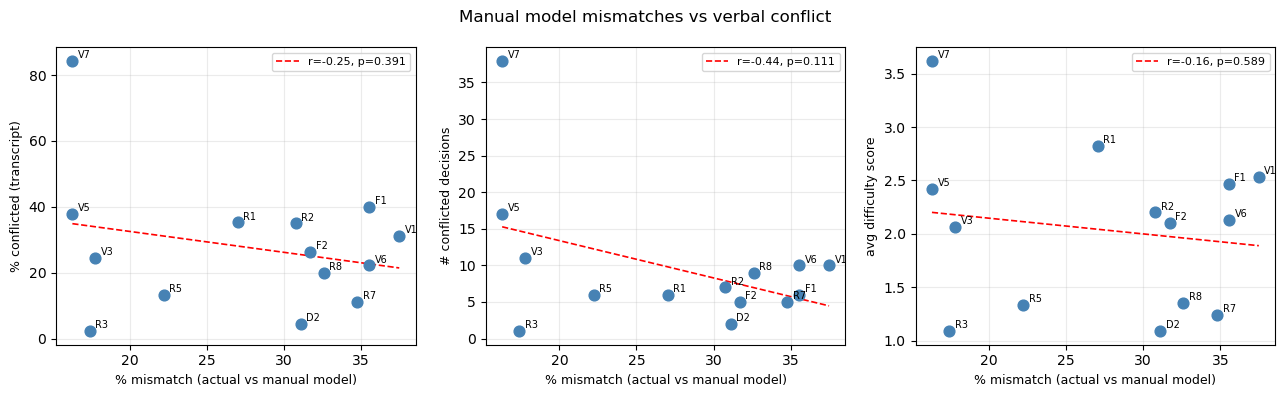

Saved mismatch_vs_conflict.png


In [34]:
# Compare mismatches per person vs verbal conflict score
import scipy.stats as stats

# --- mismatch counts (exclude ties and NaN) ---
pm = pd.read_csv('pairwise_model_predictions.csv')
pm = pm.drop_duplicates(subset=['personID','num_Q'])  # one row per comparison
pm['matches_actual'] = pm['matches_actual'].map({'True': True, 'False': False, True: True, False: False})
pm_valid = pm[pm['model_prediction'] != 'tie'].dropna(subset=['matches_actual'])
mismatch_counts = pm_valid.groupby('personID').agg(
    n_compared=('matches_actual', 'count'),
    n_mismatch=('matches_actual', lambda x: (~x.astype(bool)).sum()),
).assign(pct_mismatch=lambda d: d['n_mismatch'] / d['n_compared'] * 100)

# --- verbal conflict scores ---
td = pd.read_csv('transcript_difficulty.csv')
verbal = td.groupby('personID').agg(
    n_decisions=('num_Q', 'count'),
    n_conflicted=('conflicted', 'sum'),
    avg_difficulty=('difficulty_score', 'mean'),
).assign(pct_conflicted=lambda d: d['n_conflicted'] / d['n_decisions'] * 100)

# --- merge ---
cmp = mismatch_counts.join(verbal, how='inner')
print(cmp[['n_mismatch','pct_mismatch','n_conflicted','pct_conflicted','avg_difficulty']].round(1).to_string())

# --- scatter plots ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

pairs = [
    ('pct_mismatch',  'pct_conflicted',  '% conflicted (transcript)'),
    ('pct_mismatch',  'n_conflicted',    '# conflicted decisions'),
    ('pct_mismatch',  'avg_difficulty',  'avg difficulty score'),
]

for ax, (xcol, ycol, ylabel) in zip(axes, pairs):
    x = cmp[xcol].values
    y = cmp[ycol].values
    ax.scatter(x, y, color='steelblue', s=60, zorder=3)

    for pid, row in cmp.iterrows():
        ax.annotate(pid, (row[xcol], row[ycol]),
                    fontsize=7, xytext=(4, 2), textcoords='offset points')

    # regression line
    m, b, r, p, _ = stats.linregress(x, y)
    xfit = np.linspace(x.min(), x.max(), 100)
    ax.plot(xfit, m * xfit + b, 'r--', lw=1.2,
            label=f'r={r:.2f}, p={p:.3f}')
    ax.legend(fontsize=8)

    ax.set_xlabel('% mismatch (actual vs manual model)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle('Manual model mismatches vs verbal conflict', fontsize=12)
plt.tight_layout()
plt.savefig('mismatch_vs_conflict.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved mismatch_vs_conflict.png')
